<a href="https://colab.research.google.com/github/JenyaGL/VIX-and-google-trends-comparison/blob/main/Volatility_fear_index_comparison_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This projet investigates the correlation between the volatility fear-index and google trends seaches like 'iran' and 'oil'.


the objective is to observe the affects of the 2 distinct spheres on each other.

# **the data**

- the data is between 1st of februrary 2026 and up until 19th of match 2026.


**Google Trends SDK**

- the data contains google trends search terms from the geos US and ISR from pytrends API.

**Yfinance SDK**

- VIX fear-index of wall street from yfinance API

- XAUUSD is the current spot price of gold against the US dollar.

- OIL Brent Crude Oil

**Tase website**

- VTA35 israeli fear-index uploaded from csv file, no API access.

https://market.tase.co.il/he/market_data/index/598/historical_data/eod?pType=8&oId=598&dFrom=2026-03-01&dTo=2026-03-23


**Truth Social**

- Social platfrom in which Trump posts regularly





**hypothesis**


Donald Trumps social media posts are associated with spikes in Google Trends, which are predictions to increases in market volatility and abnormal equity returns

## **Structure**

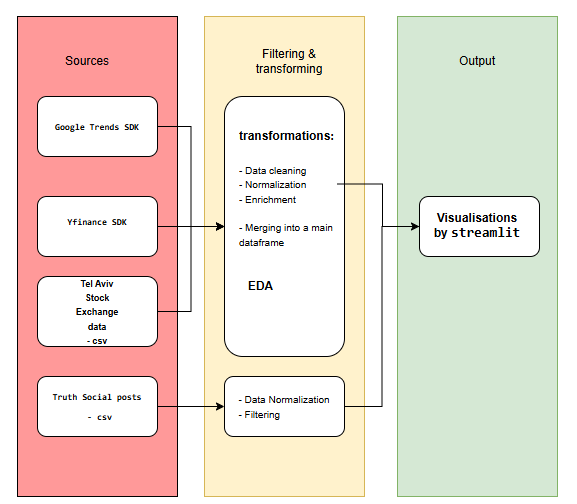

In [2]:
!pip install yfinance pytrends pyngrok streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 54.4 MB/s eta 0:00:00


In [3]:
# data processings & viz libs
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime, timedelta
import streamlit as st

# file management libs
import glob
import os

# SDKs
import yfinance as yf
from pytrends.request import TrendReq

# ignore warnings
import warnings
warnings.filterwarnings('ignore')

# enabling google colab secrets
from google.colab import userdata

# Data setup & configuration

In [56]:
# data timeframe

# setting up timeframe for extractions
end_date = datetime.today()
start_date = datetime(2026, 1, 1)


# Format for yfinance (YYYY-MM-DD)
start_str = start_date.strftime('%Y-%m-%d')
end_str = end_date.strftime('%Y-%m-%d')

# ---------------

# yfinance tickers

yfinance_tickers = {'VIX':'^VIX',
                    'OIL':'BZ=F',
                    'GOLD':'GLD'
                  }


# ---------------
# pytrends values

pytrends_values = {
    'iran_trending_us': {'term': 'Iran', 'geo': 'US', 'hl': 'en-US'},
    'iran_trending_il': {'term': 'איראן', 'geo': 'IL', 'hl': 'he-IL'},
    'oil_trending_us' : {'term': 'oil', 'geo': 'US', 'hl': 'en-US'},
    'oil_trending_il': {'term': 'נפט', 'geo': 'IL', 'hl': 'he-IL'}
                }

# Format for pytrends (YYYY-MM-DD YYYY-MM-DD)
timeframe_str = f"{start_str} {end_str}"

# ---------------

print(f"Extracting data timeframe from {start_str} to {end_str}\n")

Extracting data timeframe from 2026-01-01 to 2026-03-26



# Extract:

## Extracting data from YFinance

In [5]:
raw_yfinance_data = {}

try:
    for name, ticker in yfinance_tickers.items():
        print(f" pulling {name} {ticker}")
        raw_yfinance_data[name] = yf.download(ticker, start=start_str, end=end_str)

    print("All data has been pulled")

except ValueError:
    print(f'{ticker} not found')

except Exception as e:
    print(f'error: {e}')

 pulling VIX ^VIX


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


 pulling OIL BZ=F
 pulling GOLD GLD


[*********************100%***********************]  1 of 1 completed

All data has been pulled


In [6]:
for name,df in raw_yfinance_data.items():
  print(f'{name}:')
  print('\n'+ '='*10 )
  print(df.head(5))
  print('\n'+ '='*10 )
  print({df.info()})
  print('\n'+ '='*10 )
  print({df.shape})
  print('\n'+ '='*10 )

VIX:

Price       Close   High    Low   Open Volume
Ticker       ^VIX   ^VIX   ^VIX   ^VIX   ^VIX
Date                                         
2026-01-02  14.51  15.42  14.46  14.85      0
2026-01-05  14.90  15.27  14.65  15.14      0
2026-01-06  14.75  15.21  14.63  15.00      0
2026-01-07  15.38  15.48  14.83  14.95      0
2026-01-08  15.45  15.85  15.15  15.69      0

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 57 entries, 2026-01-02 to 2026-03-25
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, ^VIX)   57 non-null     float64
 1   (High, ^VIX)    57 non-null     float64
 2   (Low, ^VIX)     57 non-null     float64
 3   (Open, ^VIX)    57 non-null     float64
 4   (Volume, ^VIX)  57 non-null     int64  
dtypes: float64(4), int64(1)
memory usage: 2.7 KB
{None}

{(57, 5)}

OIL:

Price           Close       High        Low       Open Volume
Ticker           BZ=F       BZ=F       BZ=F       B

In [7]:
# processing and reshaping raw_yfinance_data

yfinance_tables =[]

for name, df in raw_yfinance_data.items():

  temp_df = df.copy()
  temp_df.columns = temp_df.columns.droplevel(1)

  clean_df = temp_df[['Close']].copy()
  clean_df.columns = [name]
  clean_df.columns.name = None
  clean_df.index.name = 'date'

  yfinance_tables.append(clean_df)

clean_yfinance_data = pd.concat(yfinance_tables, axis=1)

print(clean_yfinance_data.shape)
print(clean_yfinance_data.sample())



(58, 3)
              VIX        OIL        GOLD
date                                    
2026-01-16  15.86  64.129997  421.290009


# Extracting data from Google trends

In [8]:
# processing and reshaping pytrends_tables

raw_pytrends_date = {}

for name, values in pytrends_values.items():

  try:
    print(f'pulling {name}, {values['term']}')
    pytrends = TrendReq(hl=values['hl'], tz=360)

    pytrends.build_payload([values['term']], timeframe=timeframe_str, geo=values['geo'])
    raw_pytrends_date[name] = pytrends.interest_over_time()

  except Exception as error:
    print(f"failed pulling {name} data - {error}")



pulling iran_trending_us, Iran
pulling iran_trending_il, איראן
pulling oil_trending_us, oil
pulling oil_trending_il, נפט


In [9]:
for name,df in raw_pytrends_date.items():
  print(f'{name}:')
  print('\n'+ '='*10 )
  print(df.head(5))
  print('\n'+ '='*10 )
  print({df.info()})
  print('\n'+ '='*10 )
  print({df.shape})
  print('\n'+ '='*10 )

iran_trending_us:

            Iran  isPartial
date                       
2026-01-01     2      False
2026-01-02     2      False
2026-01-03     3      False
2026-01-04     2      False
2026-01-05     2      False

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 85 entries, 2026-01-01 to 2026-03-26
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Iran       85 non-null     int64
 1   isPartial  85 non-null     bool 
dtypes: bool(1), int64(1)
memory usage: 1.4 KB
{None}

{(85, 2)}

iran_trending_il:

            איראן  isPartial
date                        
2026-01-01      8      False
2026-01-02      7      False
2026-01-03      7      False
2026-01-04     10      False
2026-01-05     11      False

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 85 entries, 2026-01-01 to 2026-03-26
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   איראן      85 non-

In [10]:
pytrends_list = []

for name, df in raw_pytrends_date.items():

  temp_df = df.iloc[:, [0]].copy()
  temp_df.columns = [name]
  pytrends_list.append(temp_df)
  print(f'processed {name}')
  pytrends_data = pd.concat(pytrends_list, axis=1)



print(pytrends_data.shape)
print(pytrends_data.sample())




processed iran_trending_us
processed iran_trending_il
processed oil_trending_us
processed oil_trending_il
(85, 4)
            iran_trending_us  iran_trending_il  oil_trending_us  \
date                                                              
2026-03-10                23                23               83   

            oil_trending_il  
date                         
2026-03-10               54  


## Extracting data from TASE

In [30]:
# loading Volatilty TA35 index - has to be download and uploaded manually

folder = '/content/drive/MyDrive/VIX analysis/VTA35 Monthly'
csv_list = glob.glob(os.path.join(folder, "*.csv"))


try:
  vta35_raw = pd.concat([pd.read_csv(data,header=0,
                names=['date', 'VTA35_close', 'open', 'high', 'low', 'volume', 'change_pct'],
                parse_dates=['date'],
                date_format='%d/%m/%Y',) # read_csv
                for data in csv_list], # for iteration
                ignore_index=True)

  print(f"vta35 loaded {len(csv_list)} files")

except ValueError:
    print('no vta35 files not found')

except Exception as e:
    print(f"Error: {e}")


vta35 loaded 3 files


In [31]:
print('vta35_raw}:')
print('\n'+ '='*10 )
print(vta35_raw.head(5))
print(vta35_raw.tail(5))
print('\n'+ '='*10 )
print({vta35_raw.info()})
print('\n'+ '='*10 )
print({vta35_raw.shape})
print('\n'+ '='*10 )

vta35_raw}:

         date  VTA35_close   open   high    low  volume change_pct
0  30.01.2026        23.71  25.12  25.86  23.43     NaN     -5.61%
1  29.01.2026        25.12  22.13  25.34  21.91     NaN     11.74%
2  28.01.2026        22.48  21.30  23.01  19.91     NaN      3.17%
3  27.01.2026        21.79  21.15  21.95  20.79     NaN      4.16%
4  26.01.2026        20.92  18.57  22.07  18.57     NaN     12.65%
                   date  VTA35_close  open   high    low  volume change_pct
53  2026-03-09 00:00:00        20.74   NaN  25.67  26.87   20.74        NaN
54  2026-03-06 00:00:00        20.75   NaN  20.74  21.84   19.79        NaN
55  2026-03-05 00:00:00        23.77   NaN  20.75  24.64   20.57        NaN
56  2026-03-04 00:00:00        23.04   NaN  23.77  25.06   21.62        NaN
57  2026-03-02 00:00:00        28.14   NaN  23.04  28.14   22.21        NaN

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 7 columns):
 #   Column       Non-Null

In [35]:
# normalizing vta35_raw
try:
  vta35_raw['date'] = pd.to_datetime(vta35_raw['date'])
  vta35_clean = vta35_raw[['date','VTA35_close']].copy()
  vta35_clean = vta35_clean.rename(columns={'VTA35_close': 'VTA35'})
  vta35_clean = vta35_clean.set_index('date')
  print(vta35_clean.sample(5))

except Exception as e:
    print(f"Error: {e}")


            VTA35
date             
2026-01-21  20.02
2026-02-13  15.91
2026-01-17  21.18
2026-01-28  22.48
2026-02-27  28.14


--------------------------------------------------------------------------------

# Data Transformation & EDA

In [36]:
# EDA
sources = {
    "VTA35 - IL Market": vta35_raw,
    "Google trends": pytrends_data,
    "Yfinance closing prices": clean_yfinance_data}


for name,source in sources.items():
  print(f'{name}:')
  print('\n'+ '='*10 )
  print(source.head(5))
  print('\n'+ '='*10 )
  print(source.info())
  print('\n'+ '='*10 )
  print(source.shape)
  print('\n'+ '='*10 )
  print(source.describe())
  print('\n'+ '--'*30 )

VTA35 - IL Market:

        date  VTA35_close   open   high    low  volume change_pct
0 2026-01-30        23.71  25.12  25.86  23.43     NaN     -5.61%
1 2026-01-29        25.12  22.13  25.34  21.91     NaN     11.74%
2 2026-01-28        22.48  21.30  23.01  19.91     NaN      3.17%
3 2026-01-27        21.79  21.15  21.95  20.79     NaN      4.16%
4 2026-01-26        20.92  18.57  22.07  18.57     NaN     12.65%

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         58 non-null     datetime64[ns]
 1   VTA35_close  58 non-null     float64       
 2   open         42 non-null     float64       
 3   high         58 non-null     float64       
 4   low          58 non-null     float64       
 5   volume       16 non-null     float64       
 6   change_pct   42 non-null     object        
dtypes: datetime64[ns](1), float64(5), o

In [37]:
master_df = pd.concat([pytrends_data, vta35_clean,clean_yfinance_data], axis=1)

# we need to fill the missing values for weekend dates and the first/last rows
master_df = master_df.ffill()
master_df = master_df.bfill()


master_df.to_csv("full_data.csv", index=True)

master_df.shape

(85, 8)

In [132]:
master_df.corr()

,iran_trending_us,iran_trending_il,oil_trending_us,oil_trending_il,VTA35,VIX,OIL,GOLD
iran_trending_us,1.000000,0.868576,0.463319,0.615350,0.591556,0.389312,0.317204,0.345939
iran_trending_il,0.868576,1.000000,0.240049,0.397792,0.636745,0.185228,0.144069,0.317859
oil_trending_us,0.463319,0.240049,1.000000,0.866256,0.171902,0.701770,0.694182,0.048353
oil_trending_il,0.615350,0.397792,0.866256,1.000000,0.280904,0.691690,0.682709,0.184141
VTA35,0.591556,0.636745,0.171902,0.280904,1.000000,0.138588,0.143991,0.414776
VIX,0.389312,0.185228,0.701770,0.691690,0.138588,1.000000,0.887413,0.266466
OIL,0.317204,0.144069,0.694182,0.682709,0.143991,0.887413,1.000000,0.064149
GOLD,0.345939,0.317859,0.048353,0.184141,0.414776,0.266466,0.064149,1.000000


# Extracting from Truth social platfrom, Trumps posts


Initial Plan was to utilise native Truth Social API but io faced Cloudflare 403 blocks when using api ingestion,
so i had to pivot the method to a read_csv.

the data was pulled from https://ix.cnn.io/data/truth-social/truth_archive.json

In [40]:
t_posts_raw = pd.read_csv('/content/drive/MyDrive/VIX analysis/truth_posts/truth_archive.csv'
                ,parse_dates=['created_at'],
                date_format='%Y-%m-%d')

t_posts_raw.head()

,id,created_at,content,url,media,replies_count,reblogs_count,favourites_count
0,116291185984825094,2026-03-25T18:17:56.771Z,My meeting with the Highly Respected President...,https://truthsocial.com/@realDonaldTrump/11629...,NaN,25,94,348
1,116290852675177057,2026-03-25T16:53:10.868Z,We are asking for expedited Judicial Review be...,https://truthsocial.com/@realDonaldTrump/11629...,NaN,1040,2867,9018
2,116290846597255331,2026-03-25T16:51:38.124Z,Speaker of the House Mike Johnson and Senate M...,https://truthsocial.com/@realDonaldTrump/11629...,NaN,1117,3376,14189
3,116290799193660420,2026-03-25T16:39:34.807Z,I am so proud of our ICE Patriots! They were u...,https://truthsocial.com/@realDonaldTrump/11629...,NaN,717,2262,8710
4,116290528260288417,2026-03-25T15:30:40.726Z,"The Radical Left, Country Hating Democrats are...",https://truthsocial.com/@realDonaldTrump/11629...,NaN,1457,3056,12245


In [49]:
print(f'{t_posts_raw}:')
print('\n'+ '='*10 )
print(t_posts_raw.sample())
print('\n'+ '='*10 )
print({t_posts_raw.info()})
print('\n'+ '='*10 )
print({t_posts_raw.shape})
print('\n'+ '='*10 )

                       id                created_at  \
0      116291185984825094  2026-03-25T18:17:56.771Z   
1      116290852675177057  2026-03-25T16:53:10.868Z   
2      116290846597255331  2026-03-25T16:51:38.124Z   
3      116290799193660420  2026-03-25T16:39:34.807Z   
4      116290528260288417  2026-03-25T15:30:40.726Z   
...                   ...                       ...   
32227  108221053884053060  2022-04-30T12:37:13.451Z   
32228  108221053343991942  2022-04-30T12:37:05.206Z   
32229  108217783188791701  2022-04-29T22:45:26.592Z   
32230  108211822140637685  2022-04-28T21:29:28.207Z   
32231  107797156496908384  2022-02-14T15:54:32.528Z   

                                                 content  \
0      My meeting with the Highly Respected President...   
1      We are asking for expedited Judicial Review be...   
2      Speaker of the House Mike Johnson and Senate M...   
3      I am so proud of our ICE Patriots! They were u...   
4      The Radical Left, Country Hating

In [122]:
t_posts = t_posts_raw.dropna(subset=['content'])
t_posts['created_at'] = pd.to_datetime(t_posts['created_at']).dt.tz_localize(None)
t_posts['date'] = t_posts['created_at'].dt.date

idx = t_posts.groupby('date')['reblogs_count'].idxmax()
t_posts_clean = t_posts.loc[idx]

start_date = pd.to_datetime('2026-01-01').date()
t_posts_clean = t_posts_clean[(t_posts_clean['date'] >= start_date) & (t_posts_clean['reblogs_count'] >= 20000)] # saving only trending posts

t_posts_clean.set_index('date', inplace=True)
t_posts_clean = t_posts_clean[['content']]

t_posts_clean


,content
date,
2026-01-03,The United States of America has successfully ...
2026-01-13,"Iranian Patriots, KEEP PROTESTING - TAKE OVER ..."
2026-02-28,"Khamenei, one of the most evil people in Histo..."


In [123]:
t_posts_clean.to_csv("posts_data.csv", index=True)
t_posts_clean.shape

(3, 1)

Visual Analysis

In [124]:
import textwrap

# 1. Define a function to wrap text for Plotly
def wrap_hover_text(text, width=70):
    if not isinstance(text, str):
        return ""
    return '<br>'.join(textwrap.wrap(text, width=width))

# 2. Apply it to your Truth Social dataframe to create a new column
t_posts_clean['wrapped_content'] = t_posts_clean['content'].apply(wrap_hover_text)

# 1. Create a 2-row figure.
# Row 1 is standard. Row 2 gets the dual Y-axis for Commodities vs Indices!
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
    subplot_titles=("Public Interest (Google Trends)", "Market & Commodity Response"),
    specs=[[{"secondary_y": False}], [{"secondary_y": True}]])

# 1. Create a figure that explicitly allows a secondary Y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

# GROUP 1: Indices & Search Trends (Left Axis, secondary_y=False)
fig.add_trace(
    go.Scatter(x=master_df.index, y=master_df['VIX'], name="VIX (US Market Volatility)",
               line=dict(color='red', width=3)),
    secondary_y=False
)
fig.add_trace(
    go.Scatter(x=master_df.index, y=master_df['VTA35'], name="VTA35 (IL Market Volatility)",
               line=dict(color='darkorange', width=3)),
    secondary_y=False
)
fig.add_trace(
    go.Scatter(x=master_df.index, y=master_df['iran_trending_us'], name="US Search: 'Iran'",
               line=dict(color='blue', dash='dot', width=2)),
    secondary_y=False
)
fig.add_trace(
    go.Scatter(x=master_df.index, y=master_df['iran_trending_il'], name="IL Search: 'איראן'",
               line=dict(color='purple', dash='dot', width=2)),
    secondary_y=False
)
fig.add_trace(
    go.Scatter(x=master_df.index, y=master_df['oil_trending_us'], name="US Search: 'oil'",
    line=dict(color='crimson', dash='dot', width=2)),
    secondary_y=False)

fig.add_trace(
    go.Scatter(x=master_df.index, y=master_df['oil_trending_il'], name="IL Search: 'נפט'",
    line=dict(color='cornflowerblue', dash='dot', width=2)),
    secondary_y=False)


# GROUP 2: Commodities in USD (Right Axis, secondary_y=True)
fig.add_trace(
    go.Scatter(x=master_df.index, y=master_df['OIL'], name="Oil Price (USD)",
               line=dict(color='green', width=3)),
    secondary_y=True
)
fig.add_trace(
    go.Scatter(x=master_df.index, y=master_df['GOLD'], name="Gold Price (USD)",
               line=dict(color='gold', width=3)),
    secondary_y=True
)

# GROUP 3: Trump's Truth Social Posts
fig.add_trace(
    go.Scatter(
        x=t_posts_clean.index,
        y=[100] * len(t_posts_clean),
        mode='markers',
        name='Trump Truths',
        marker=dict(symbol='pentagon', size=14, color='orange', line=dict(color='white', width=1)),

        # USE THE NEW WRAPPED COLUMN HERE!
        hovertext=t_posts_clean['wrapped_content'],

        hoverinfo='text',
        showlegend=True
    ),
    secondary_y=False
)

# --- LAYOUT & STYLING ---
fig.update_layout(
    title_text="Macro-Economic Impact of Geopolitical Sentiment (YTD 2026)",
    height=700,
    template="plotly_dark",
    hovermode="x unified" # Creates a single vertical line showing all 6 values on hover
)


# Clearly label what each side of the chart represents
fig.update_yaxes(title_text="Trends & Volatility Index (%)", secondary_y=False)
fig.update_yaxes(title_text="Price (USD)", secondary_y=True)

# Render the chart!
fig.show()

In [125]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import textwrap

# 1. Define a function to wrap text for Plotly
def wrap_hover_text(text, width=70):
    if not isinstance(text, str):
        return ""
    return '<br>'.join(textwrap.wrap(text, width=width))

# 2. Apply it to your Truth Social dataframe to create a new column
t_posts_clean['wrapped_content'] = t_posts_clean['content'].apply(wrap_hover_text)

# 1. Create a 2-row figure.
# Row 1 is standard. Row 2 gets the dual Y-axis for Commodities vs Indices!
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
    subplot_titles=("Public Interest (Google Trends)", "Market & Commodity Response"),
    specs=[[{"secondary_y": False}], [{"secondary_y": True}]]
)



# --- ROW 1: GOOGLE TRENDS (Top Chart) ---
fig.add_trace(
    go.Scatter(x=master_df.index, y=master_df['iran_trending_us'], name="US Search: 'Iran'",
               line=dict(color='blue', dash='dot', width=2)),
    row=1, col=1)

fig.add_trace(
    go.Scatter(x=master_df.index, y=master_df['iran_trending_il'], name="IL Search: 'איראן'",
               line=dict(color='purple', dash='dot', width=2)),
    row=1, col=1)

fig.add_trace(
    go.Scatter(x=master_df.index, y=master_df['oil_trending_us'], name="US Search: 'oil'",
               line=dict(color='crimson', dash='dot', width=2)),
    row=1, col=1)

fig.add_trace(
    go.Scatter(x=master_df.index, y=master_df['oil_trending_il'], name="IL Search: 'נפט'",
               line=dict(color='cornflowerblue', dash='dot', width=2)),
    row=1, col=1)


# --- ROW 2: INDICES (Bottom Chart, Left Axis) ---
fig.add_trace(
    go.Scatter(x=master_df.index, y=master_df['VIX'], name="VIX (US Market Volatility)",
               line=dict(color='red', width=3)),
    row=2, col=1, secondary_y=False)

fig.add_trace(
    go.Scatter(x=master_df.index, y=master_df['VTA35'], name="VTA35 (IL Market Volatility)",
               line=dict(color='darkorange', width=3)),
    row=2, col=1, secondary_y=False)



# --- ROW 2: COMMODITIES (Bottom Chart, Right Axis) ---
fig.add_trace(
go.Scatter(x=master_df.index, y=master_df['OIL'], name="Oil Price (USD)",
line=dict(color='green', width=3)),
row=2, col=1, secondary_y=True)

fig.add_trace(
go.Scatter(x=master_df.index, y=master_df['GOLD'], name="Gold Price (USD)",
line=dict(color='gold', width=3)),
row=2, col=1, secondary_y=True)

# GROUP 3: Trump's Truth Social Posts
fig.add_trace(
    go.Scatter(
        x=t_posts_clean.index,
        y=[100] * len(t_posts_clean),
        mode='markers',
        name='Trump Truths',
        marker=dict(symbol='pentagon', size=14, color='orange', line=dict(color='white', width=1)),

        # USE THE NEW WRAPPED COLUMN HERE!
        hovertext=t_posts_clean['wrapped_content'],

        hoverinfo='text',
        showlegend=True
    ),
    secondary_y=False
)

# --- LAYOUT & STYLING ---
fig.update_layout(
title_text="Macro-Economic Impact of Geopolitical Sentiment (YTD 2026)",
height=800, # Made the chart slightly taller to comfortably fit both rows
template="plotly_dark",
hovermode="x unified"
)



# Clearly label all THREE Y-axes!
fig.update_yaxes(title_text="Trend Score (0-100)", row=1, col=1)
fig.update_yaxes(title_text="Volatility Index", row=2, col=1, secondary_y=False)
fig.update_yaxes(title_text="Price (USD)", row=2, col=1, secondary_y=True)



# Render the chart!
fig.show()

In [133]:
%%writefile app.py
import streamlit as st
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import textwrap


# PAGE SETUP
st.set_page_config(page_title="Google trends Market volatility", layout="wide")

st.markdown("""
    <style>
    .stApp { background-color: #f0f2f6; }
    .metric-card {
        background-color: #e0e4ef;
        border: 1px solid #cfd4e0;
        padding: 20px;
        border-radius: 4px;
        text-align: center;
        height: 140px;
        display: flex;
        flex-direction: column;
        justify-content: center;
    }
    .metric-label { font-size: 13px; font-weight: 600; color: #4f5b66; text-transform: uppercase; }
    .metric-value { font-size: 28px; font-weight: 800; color: #1a1c23; }
    h1 { color: #1a1c23 !important; }
    </style>
    """, unsafe_allow_html=True)

@st.cache_data
def load_data(path):
    df = pd.read_csv(path, encoding='utf-8-sig')
    df.columns = [str(c).strip().lower() for c in df.columns]
    date_col = next((c for c in df.columns if 'date' in c), df.columns[0])
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).set_index(date_col)
    return df

master_df = load_data("/content/full_data.csv")
posts_df = load_data("/content/posts_data.csv")

# Safety helper to prevent crashes if columns are missing
def get_val(name):
    return master_df[name] if name in master_df.columns else pd.Series(0, index=master_df.index)


# SIDEBAR INTERACTIVITY
st.sidebar.header("Dashboard Controls")
region_focus = st.sidebar.selectbox("Region Focus", ["Global (All)", "United States", "Israel"])

# Define Event Markers (The text will appear on HOVER)
events = {
    "2026-02-28": "US & Israeli strikes on iran soil",
    "2026-03-23": "Trump delays US attacks on Iran energy infrastructure.",
    "2026-03-09": "Public panic regarding oil prices",
    "2026-01-03": "Maduro is captured and kidnapped in a US military operation"
}

# ANALYTICS
oil_series = get_val('oil')
min_price = oil_series.iloc[0]
current_price = oil_series.iloc[-1]
pct_change = ((current_price - min_price) / min_price) * 100

peak_val = oil_series.max()
peak_date = oil_series.idxmax().strftime('%Y-%m-%d')

# HEADER
st.title("Sentiment-Driven Volatility Analysis")
col1, col2, col3 = st.columns([2, 1, 1])
with col2:
    st.markdown(f'<div class="metric-card"><div class="metric-label">Oil Growth</div><div class="metric-value">{pct_change:.2f}%</div></div>', unsafe_allow_html=True)
with col3:
    st.markdown(f'<div class="metric-card"><div class="metric-label">Oil Peak ({peak_date})</div><div class="metric-value">${peak_val:.2f}</div></div>', unsafe_allow_html=True)

# PLOTTING
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.1,
                    subplot_titles=("Google Sentiment Trends", "Financial Market Response"),
                    specs=[[{"secondary_y": False}], [{"secondary_y": True}]])

# Function to handle region focus (Fades out non-selected data)
def get_opacity(name):
    if region_focus == "Global (All)": return 1.0
    if region_focus == "United States" and ("us" in name.lower() or "vix" in name.lower()): return 1.0
    if region_focus == "Israel" and ("il" in name.lower() or "vta" in name.lower()): return 1.0
    return 0.15

# Row 1: Trends
for col, name, color in [('iran_trending_us', 'US Search Iran', '#0072B2'),
                         ('iran_trending_il', 'IL Search Iran', 'crimson'),
                         ('oil_trending_us', 'US Search Oil', '#D55E00'),
                         ('oil_trending_il', 'IL Search OIL', 'cornflowerblue')]:

    fig.add_trace(go.Scatter(x=master_df.index, y=master_df[col],
                             name=name, opacity=get_opacity(col),
                             line=dict(color=color)), row=1, col=1)


# Row 2: Market
fig.add_trace(go.Scatter(x=master_df.index, y=get_val('vix'),
                         name="VIX", opacity=get_opacity('vix'),
                         line=dict(color='#CC79A7')), row=2, col=1,
                         secondary_y=False)

fig.add_trace(go.Scatter(x=master_df.index, y=get_val('vta35'),
                         name="VTA35", opacity=get_opacity('vta35'),
                         line=dict(color='#000000')), row=2, col=1,
                         secondary_y=False)

fig.add_trace(go.Scatter(x=master_df.index, y=get_val('oil'), name="Oil", line=dict(width=4, color='#009E73')), row=2, col=1, secondary_y=True)

fig.add_trace(go.Scatter(x=master_df.index, y=get_val('gold'), name="Gold", line=dict(color='#E69F00')), row=2, col=1, secondary_y=True)


# Truth Social posts:

def wrap_hover_text(text, width=70):
    if not isinstance(text, str):
        return ""
    return '<br>'.join(textwrap.wrap(text, width=width))

posts_df['wrapped_content'] = posts_df['content'].apply(wrap_hover_text)

fig.add_trace(
    go.Scatter(
        x=posts_df.index,
        y=[95] * len(posts_df),
        mode='markers',
        name='Trump Truths Social posts',
        marker=dict(symbol='pentagon', size=14, color='orange', line=dict(color='white', width=1)),

        hovertext=posts_df['wrapped_content'],

        hoverinfo='text',
        showlegend=True
    ),
    secondary_y=False
)

# INTERACTIVE EVENT MARKERS (Hover only)
for date_str, text in events.items():
    # Convert string key to datetime to match index
    event_date = pd.to_datetime(date_str)
    if event_date in master_df.index:
        # 1. Vertical Line
        fig.add_vline(x=date_str, line_dash="dash", line_color="rgba(255, 0, 0, 0.4)", row="all", col=1)

        # 2. Invisible trace for Hover interaction
        fig.add_trace(go.Scatter(
            x=[event_date, event_date],
            y=[master_df.min().min(), master_df.max().max() * 1.5],
            mode="lines",
            line=dict(color="rgba(0,0,0,0)"),
            hoverinfo="text",
            hovertext=text,
            showlegend=False,
            name="Event Brief"
        ), row=1, col=1)

fig.update_layout(height=800, template="plotly_white", hovermode="x unified", margin=dict(t=80))

# Axis Labels
fig.update_yaxes(title_text="Trend Score",range=[1, 100], row=1, col=1)
fig.update_yaxes(title_text="Volatility", row=2, col=1, secondary_y=False)
fig.update_yaxes(title_text="USD Price", row=2, col=1, secondary_y=True)

st.plotly_chart(fig, use_container_width=True)

Overwriting app.py


In [127]:
from pyngrok import ngrok


# create an accoiunt and generate a token:
# https://dashboard.ngrok.com/get-started/your-authtoken

# Connect Ngrok (using your existing token)
ngrok_token = userdata.get('NGROK_TOKEN')
ngrok.set_auth_token(ngrok_token) # add your own ngrok token here

# 1. Force-kill everything old to free up your Ngrok limit
!pkill streamlit
!pkill ngrok
ngrok.kill()

# 2. Start Streamlit in the background
# We pipe logs to 'nohup.out' so we can debug if it crashes
os.system("nohup streamlit run app.py &")

# Connect Ngrok (using your existing token)

ngrok.set_auth_token(ngrok_token) # add your own ngrok token here

try:
    public_url = ngrok.connect(8501, proto="http")
    print(f" dashboars is live {public_url}")
except Exception as e:
    print(f"Error: {e}")

 dashboars is live NgrokTunnel: "https://desired-jefferey-preaffirmative.ngrok-free.dev" -> "http://localhost:8501"


Conclusion

This data pipeline tracks social media, public search behavior, and financial metrics.

The data reveals a clear, sequential relationship between digital sentiment and macroeconomic impact. Geopolitical rhetoric does not just create noise; it creates a measurable, cascading shockwave through global markets.

# **Key Findings**

**The Sequential Ripple Effect:**

The data demonstrates that market reactions are
not random, but follow a predictable chain of events. A geopolitical catalyst (high-profile Truth Social posts regarding international relations) first triggers a localized spike in public awareness (Google Search trends). Within days, this translates into economic anxiety (Search trends for "Oil" peaking at 100 on March 9th), which ultimately forces commodity prices (Oil breaking $110+) and fear indices (VIX/VTA35) upward.


**Social Media as a Leading Indicator:**

 Filtering Truth Social posts by their "viral impact" (reblog volume) proves that highly amplified political rhetoric acts as a precursor to market instability. These posts serve as an early warning system for event-driven volatility before traditional economic reports are published.


**Global vs. Local Contagion:**

By comparing the US VIX with the Israeli VTA35, the dashboard illustrates how Middle Eastern geopolitical tensions bridge the gap between regional instability and global commodity pricing. The synchronous spikes in both US and IL search trends confirm that public economic fear transcends borders instantly.


**Business Value & Application:**

This dashboard illustrates the necessity of alternative data. Traditional financial indicators lag behind real-time events. By engineering a pipeline that ingests unstructured social sentiment and search volume, financial institutions can better anticipate volatility windows and adjust their exposure to high-risk commodities before the VIX peaks.

